In [30]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
%matplotlib inline

In [31]:
# Read all the words
words = open('names.txt', 'r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [32]:
len(words)

32033

In [33]:
#Build Vocabulary and mappings strings/integers

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [34]:
# Build dataset
block_size = 8 # Context length

def build_dataset(words):

    X, Y = [], [] 

    for w in words:
        context = [0]*block_size
        for char in w + '.':
            ix = stoi[char]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '===>', itos[ix])
            context = context[1:] + [ix]
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y
        
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [35]:
#Xtr.shape, Ytr.shape #Data set
for x, y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '===>', itos[y.item()])
#Xte.shape, Yte.shape #Data set

........ ===> y
.......y ===> u
......yu ===> h
.....yuh ===> e
....yuhe ===> n
...yuhen ===> g
..yuheng ===> .
........ ===> d
.......d ===> i
......di ===> o
.....dio ===> n
....dion ===> d
...diond ===> r
..diondr ===> e
.diondre ===> .
........ ===> x
.......x ===> a
......xa ===> v
.....xav ===> i
....xavi ===> e


In [24]:
g = torch.Generator().manual_seed(2147483647 + 10)
# Sample

for i in range(20):
    out = []
    context = [0] * 3
    while True:
        ix = 0
        emb = C[torch.tensor([context])] #[1, 3, 10]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2 
        #print(logits.shape)
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        context = context[1:] + [ix]

        if ix==0:
           break 
    print(''.join(out))

NameError: name 'C' is not defined

In [25]:
# Summary 

In [70]:
class Linear:
    
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
#========================================================================

class BatchNorm1d:
    
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # Parameters trained with back-prop
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # Buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
        
    def __call__(self, x):
        # Calculate forward pass
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0, 1)
            xmean = x.mean(dim, keepdim=True)# Batch mean
            xvar = x.var(dim, keepdim= True)# Batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # Normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # Update buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum)*self.running_mean + self.momentum*xmean
                self.running_var = (1 - self.momentum)*self.running_var + self.momentum*xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
#===================================================================================
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    
#===================================================================================
    
class Embedding:
    
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))
        
    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    
#===================================================================================

class FlattenConsecutive:
    
    def __init__(self, n): 
        self.n = n
    
    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []
    
class Sequential:
    
    def __init__(self, layers):
        self.layers = layers
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [71]:
torch.manual_seed(42)

In [72]:
n_embed = 10
n_hidden = 68

  
model = Sequential([
    Embedding(vocab_size, n_embed),
    FlattenConsecutive(2), Linear(n_embed * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])
#print(layers[2])

with torch.no_grad():
    # Last layer: make less confident
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

22397


In [73]:
#ix = torch.randint(0, Xtr.shape[0], (4,))
#Xb, Yb = Xtr[ix], Ytr[ix]
#logits = model(Xb)
#print(Xb.shape)
#Xb
e = torch.randn(32, 4, 68)
emean = e.mean((0, 1), keepdim=True)
evar = e.var((0, 1), keepdim=True)
ehat = (e - emean) / torch.sqrt(evar + 1e-5)
print("mean", emean.shape)
ehat.shape

mean torch.Size([1, 1, 68])


torch.Size([32, 4, 68])

In [67]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (32, 8, 10)
FlattenConsecutive : (32, 4, 20)
Linear : (32, 4, 68)
BatchNorm1d : (32, 4, 68)
Tanh : (32, 4, 68)
FlattenConsecutive : (32, 2, 136)
Linear : (32, 2, 68)
BatchNorm1d : (32, 2, 68)
Tanh : (32, 2, 68)
FlattenConsecutive : (32, 136)
Linear : (32, 68)
BatchNorm1d : (32, 68)
Tanh : (32, 68)
Linear : (32, 27)


In [69]:
model.layers[3].running_mean.shape

torch.Size([1, 1, 68])

In [74]:
batch_size = 32
max_steps = 200000
lossi = []

for i in tqdm(range(max_steps)):
    
    # Mini-batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb = Xtr[ix]
    Yb = Ytr[ix]
    
    # Forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)
    
    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # Update 
    lr = 0.1 if i < 100000 else 0.01
    
    for p in parameters:
        p.data += -lr * p.grad
    
    #Track stat 
    if i % 1000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    #stepi.append(i)
    #break
    
#print(loss.item())

  0%|          | 0/200000 [00:00<?, ?it/s]

      0/ 200000: 3.3055


  1%|          | 1019/200000 [00:04<09:48, 338.17it/s]

   1000/ 200000: 2.5094


  1%|          | 2071/200000 [00:08<09:04, 363.64it/s]

...

 99%|█████████▉| 198059/200000 [15:27<00:05, 324.48it/s]

 198000/ 200000: 1.7475


100%|█████████▉| 199049/200000 [15:32<00:02, 331.19it/s]

 199000/ 200000: 1.9972


100%|██████████| 200000/200000 [15:36<00:00, 213.54it/s]


In [75]:
@torch.no_grad()

def split_loss(split):
    x,y = {'train': (Xtr, Ytr),
          'val' : (Xdev, Ydev),
          'test' : (Xte, Yte),}[split]
    # Forward pass
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9198493957519531
val 2.028568744659424


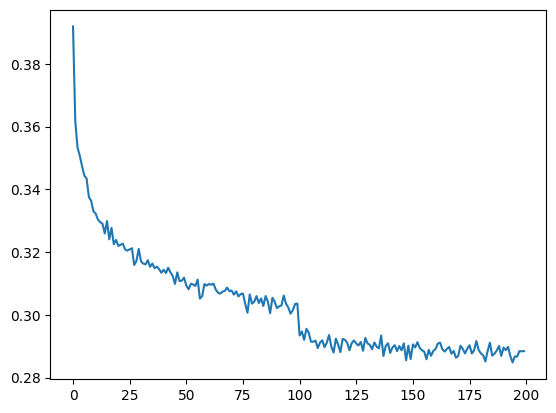

In [76]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [77]:
# put layers into eval mode (needed for batch norm especially)
for layer in model.layers:
    #if isinstance(layer, BatchNorm1d):
        #print("go")
    layer.training = False

In [78]:
# Sample

for i in range(20):
    out = []
    context = [0] * block_size
    while True:
        ix = 0
        logits = model(torch.tensor([context]))
        #print(logits.shape)
        probs = F.softmax(logits, dim=1)
        #print(probs)
        ix = torch.multinomial(probs, num_samples=1, replacement=True).item()
        out.append(itos[ix])
        context = context[1:] + [ix]

        if ix==0:
           break 
    print(''.join(out))

maleise.
lailee.
kayalyn.
hudy.
cora.
kareane.
reddik.
cashvyn.
avyane.
velter.
rayann.
dailan.
lo.
balaria.
johan.
mekly.
kie.
louken.
paryzer.
nejalia.


In [ ]:
courage ! Maman ;-)